# 🏴󠁧󠁢󠁥󠁮󠁧󠁿 Fantasy Premier League (FPL) — Data Extractor

**API Base URL:** `https://fantasy.premierleague.com/api/`  
**Sin autenticación** — API pública oficial de FPL  
**Temporada actual:** 2025/26

## 📦 1. Imports y configuración

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Configuración visual
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Base URL de la API
BASE_URL = 'https://fantasy.premierleague.com/api/'

# ── Carpeta de salida CSV
DATA_DIR = Path('fpl_data')
DATA_DIR.mkdir(exist_ok=True)

print('✅ Setup completado')

✅ Setup completado


## 🔗 2. Endpoints disponibles en la FPL API

| Endpoint | Descripción |
|---|---|
| `bootstrap-static/` | **Master endpoint**: jugadores, equipos, gameweeks, reglas de puntuación |
| `fixtures/` | Todos los partidos de la temporada (fecha, local, visitante, resultado) |
| `element-summary/{player_id}/` | Historial partido a partido de un jugador |
| `event/{gw}/live/` | Puntos en vivo por jugador en un gameweek específico |
| `entry/{manager_id}/` | Perfil de un manager de FPL |
| `entry/{manager_id}/history/` | Historial de puntos por gameweek de un manager |
| `entry/{manager_id}/event/{gw}/picks/` | Alineación de un manager en un GW específico |
| `leagues-classic/{league_id}/standings/` | Clasificación de una liga clásica |

## 📊 3. Bootstrap-Static: el endpoint maestro

In [2]:
def get_fpl_data(endpoint):
    """Hace una petición a la FPL API y devuelve JSON."""
    url = BASE_URL + endpoint
    response = requests.get(url, timeout=10)
    response.raise_for_status()
    return response.json()

# ── Descarga el master endpoint
print('📡 Conectando a FPL API...')
bootstrap = get_fpl_data('bootstrap-static/')
print(f'✅ Conexión exitosa. Claves disponibles: {list(bootstrap.keys())}')

📡 Conectando a FPL API...
✅ Conexión exitosa. Claves disponibles: ['chips', 'events', 'game_settings', 'game_config', 'phases', 'teams', 'total_players', 'element_stats', 'element_types', 'elements']


## 👥 4. Jugadores (elements)

In [3]:
# ── DataFrame de jugadores
players = pd.DataFrame(bootstrap['elements'])

# Columnas más relevantes
cols_key = [
    'id', 'web_name', 'first_name', 'second_name', 'team',
    'element_type', 'now_cost', 'total_points', 'points_per_game',
    'minutes', 'goals_scored', 'assists', 'clean_sheets',
    'goals_conceded', 'yellow_cards', 'red_cards',
    'bonus', 'bps', 'form', 'selected_by_percent',
    'transfers_in', 'transfers_out',
    'expected_goals', 'expected_assists',
    'expected_goal_involvements', 'expected_goals_conceded',
    'influence', 'creativity', 'threat', 'ict_index',
    'status', 'news', 'chance_of_playing_next_round'
]

df_players = players[cols_key].copy()

# Conversiones numéricas
numeric_cols = ['now_cost', 'total_points', 'minutes', 'goals_scored',
                'assists', 'clean_sheets', 'bonus', 'bps',
                'expected_goals', 'expected_assists',
                'expected_goal_involvements', 'expected_goals_conceded',
                'influence', 'creativity', 'threat', 'ict_index',
                'selected_by_percent', 'form', 'points_per_game']
df_players[numeric_cols] = df_players[numeric_cols].apply(pd.to_numeric, errors='coerce')

# El precio real es now_cost / 10 (en millones £)
df_players['price_M'] = df_players['now_cost'] / 10

# Mapa de posición
position_map = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}
df_players['position'] = df_players['element_type'].map(position_map)

print(f'📊 Total jugadores: {len(df_players)}')
print(f'📊 Columnas: {len(df_players.columns)}')
df_players.head(3)

📊 Total jugadores: 820
📊 Columnas: 35


,id,web_name,first_name,second_name,team,element_type,now_cost,total_points,points_per_game,minutes,...,expected_goals_conceded,influence,creativity,threat,ict_index,status,news,chance_of_playing_next_round,price_M,position
0,1,Raya,David,Raya Martín,1,1,60,122,4.1,2700,...,21.25,425.8,33.4,0.0,46.0,a,,NaN,6.0,GKP
1,2,Arrizabalaga,Kepa,Arrizabalaga Revuelta,1,1,41,0,0.0,0,...,0.00,0.0,0.0,0.0,0.0,a,,NaN,4.1,GKP
2,3,Hein,Karl,Hein,1,1,40,0,0.0,0,...,0.00,0.0,0.0,0.0,0.0,u,Has joined Werder Bremen on loan for the rest ...,0.0,4.0,GKP


In [4]:
# ── Top 10 jugadores por puntos totales
top_players = (
    df_players[df_players['status'] == 'a']   # solo disponibles
    .sort_values('total_points', ascending=False)
    [['web_name', 'position', 'price_M', 'total_points',
      'goals_scored', 'assists', 'clean_sheets', 'form']]
    .head(10)
)
print('🏆 Top 10 jugadores disponibles (por puntos totales):')
top_players

🏆 Top 10 jugadores disponibles (por puntos totales):


,web_name,position,price_M,total_points,goals_scored,assists,clean_sheets,form
513,Haaland,FWD,14.6,195,22,7,10,3.2
483,Semenyo,MID,8.3,172,15,6,8,8.2
540,B.Fernandes,MID,10.1,166,7,14,4,6.2
4,Gabriel,DEF,7.2,164,3,4,13,5.8
289,João Pedro,FWD,7.7,160,14,9,10,9.5
19,Rice,MID,7.4,160,4,9,13,5.2
7,J.Timber,DEF,6.3,148,3,6,13,5.4
209,Thiago,FWD,7.2,143,18,1,7,3.0
348,Tarkowski,DEF,5.7,136,1,1,10,5.0
761,Bowen,FWD,7.5,135,8,6,5,5.0


In [5]:
# ── Value for Money: puntos por millón de £
df_players['pts_per_million'] = df_players['total_points'] / df_players['price_M']

best_value = (
    df_players[(df_players['status'] == 'a') & (df_players['total_points'] > 30)]
    .sort_values('pts_per_million', ascending=False)
    [['web_name', 'position', 'price_M', 'total_points', 'pts_per_million']]
    .head(10)
)
print('💰 Mejores jugadores por valor (puntos/millón £):')
best_value

💰 Mejores jugadores por valor (puntos/millón £):


,web_name,position,price_M,total_points,pts_per_million
485,Guéhi,DEF,5.2,133,25.576923
135,Senesi,DEF,5.0,126,25.200000
360,Garner,MID,5.2,129,24.807692
645,Ballard,DEF,4.6,114,24.782609
682,Alderete,DEF,4.1,100,24.390244
228,Van Hecke,DEF,4.4,107,24.318182
439,Stach,MID,4.7,114,24.255319
497,O'Reilly,DEF,5.1,123,24.117647
348,Tarkowski,DEF,5.7,136,23.859649
621,Anderson,MID,5.5,131,23.818182


## 🏟️ 5. Equipos (teams)

In [6]:
# ── DataFrame de equipos
teams_raw = pd.DataFrame(bootstrap['teams'])
teams_cols = [
    'id', 'name', 'short_name', 'strength',
    'strength_overall_home', 'strength_overall_away',
    'strength_attack_home', 'strength_attack_away',
    'strength_defence_home', 'strength_defence_away'
]
df_teams = teams_raw[teams_cols].copy()

# Unir nombre de equipo a jugadores
df_players = df_players.merge(
    df_teams[['id', 'name', 'short_name']].rename(columns={'id': 'team', 'name': 'team_name', 'short_name': 'team_short'}),
    on='team', how='left'
)

print('✅ Equipos cargados:')
df_teams[['name', 'short_name', 'strength']].to_string(index=False)

✅ Equipos cargados:


"          name short_name  strength\n       Arsenal        ARS         5\n   Aston Villa        AVL         3\n       Burnley        BUR         2\n   Bournemouth        BOU         3\n     Brentford        BRE         3\n      Brighton        BHA         3\n       Chelsea        CHE         4\nCrystal Palace        CRY         3\n       Everton        EVE         3\n        Fulham        FUL         3\n         Leeds        LEE         3\n     Liverpool        LIV         4\n      Man City        MCI         4\n       Man Utd        MUN         4\n     Newcastle        NEW         3\n Nott'm Forest        NFO         3\n    Sunderland        SUN         3\n         Spurs        TOT         3\n      West Ham        WHU         3\n        Wolves        WOL         2"

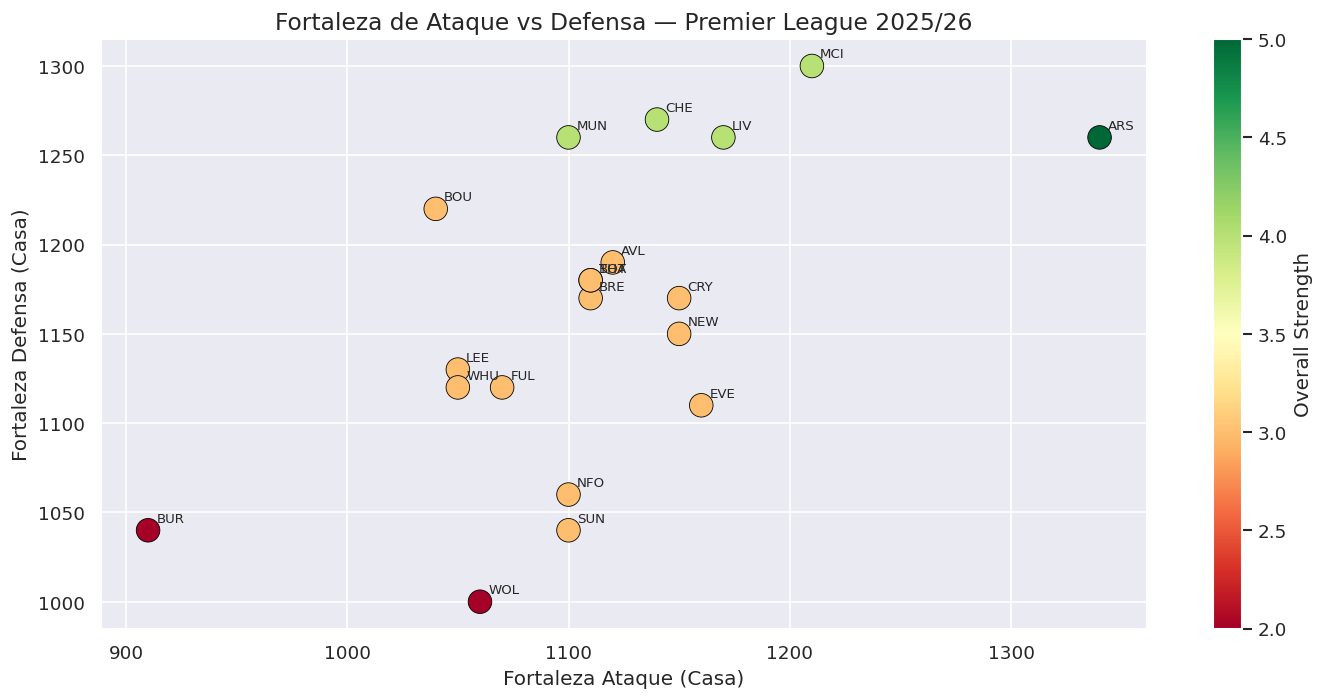

📊 Gráfico guardado en fpl_data/team_strength.png


In [7]:
# Visualización: Fortaleza de ataque vs. defensa por equipo
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    df_teams['strength_attack_home'],
    df_teams['strength_defence_home'],
    s=200, c=df_teams['strength'], cmap='RdYlGn',
    edgecolors='black', linewidth=0.5
)
for _, row in df_teams.iterrows():
    ax.annotate(row['short_name'],
                (row['strength_attack_home'], row['strength_defence_home']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_xlabel('Fortaleza Ataque (Casa)', fontsize=12)
ax.set_ylabel('Fortaleza Defensa (Casa)', fontsize=12)
ax.set_title('Fortaleza de Ataque vs Defensa — Premier League 2025/26', fontsize=14)
plt.colorbar(scatter, label='Overall Strength')
plt.tight_layout()
plt.savefig(DATA_DIR / 'team_strength.png', dpi=150)
plt.show()
print('📊 Gráfico guardado en fpl_data/team_strength.png')

## 📅 6. Gameweeks

In [8]:
# ── DataFrame de gameweeks
gw_cols = [
    'id', 'name', 'deadline_time', 'average_entry_score',
    'highest_score', 'finished', 'is_current', 'is_next',
    'transfers_made', 'ranked_count'
]
df_gw = pd.DataFrame(bootstrap['events'])[gw_cols].copy()
df_gw['deadline_time'] = pd.to_datetime(df_gw['deadline_time'])

# GW actual
current_gw = df_gw[df_gw['is_current']]
next_gw = df_gw[df_gw['is_next']]

print(f"📅 GW actual: {current_gw['name'].values[0] if len(current_gw) > 0 else 'N/A'}")
print(f"📅 Próximo GW: {next_gw['name'].values[0] if len(next_gw) > 0 else 'N/A'}")
print(f"👥 Total managers registrados: {df_gw['ranked_count'].max():,}")

# Promedio de puntos por GW
completed_gw = df_gw[df_gw['finished']]
print(f"\n📊 Promedio de puntos por GW finalizados:")
print(f"  Mean: {completed_gw['average_entry_score'].mean():.1f}")
print(f"  Max en una jornada: {completed_gw['average_entry_score'].max()}")
print(f"  Mejor puntuación individual GW: {completed_gw['highest_score'].max()}")

📅 GW actual: Gameweek 29
📅 Próximo GW: Gameweek 30
👥 Total managers registrados: 12,878,906

📊 Promedio de puntos por GW finalizados:
  Mean: 50.2
  Max en una jornada: 66
  Mejor puntuación individual GW: 149.0


## 🏃 7. Fixtures (calendario)

In [9]:
# ── Descargar fixtures
fixtures_raw = get_fpl_data('fixtures/')
df_fixtures = pd.DataFrame(fixtures_raw)

# Unir nombres de equipos
team_id_name = dict(zip(df_teams['id'], df_teams['name']))
df_fixtures['home_team'] = df_fixtures['team_h'].map(team_id_name)
df_fixtures['away_team'] = df_fixtures['team_a'].map(team_id_name)

# Solo partidos jugados
played = df_fixtures[df_fixtures['finished']].copy()
played['resultado'] = played['team_h_score'].astype(str) + ' - ' + played['team_a_score'].astype(str)

print(f'✅ Total fixtures: {len(df_fixtures)}')
print(f'✅ Partidos jugados: {len(played)}')
print('\n📋 Últimos 5 partidos jugados:')
played[['event', 'home_team', 'resultado', 'away_team']].tail(5).to_string(index=False)

✅ Total fixtures: 380
✅ Partidos jugados: 291

📋 Últimos 5 partidos jugados:


" event home_team resultado      away_team\n  29.0  Brighton 0.0 - 1.0        Arsenal\n  29.0    Fulham 0.0 - 1.0       West Ham\n  29.0  Man City 2.0 - 2.0  Nott'm Forest\n  29.0 Newcastle 2.0 - 1.0        Man Utd\n  29.0     Spurs 1.0 - 3.0 Crystal Palace"

In [10]:
# ── Tabla de goles por equipo en casa vs fuera
home_goals = played.groupby('home_team')['team_h_score'].sum().reset_index()
away_goals = played.groupby('away_team')['team_a_score'].sum().reset_index()
home_goals.columns = ['team', 'home_goals']
away_goals.columns = ['team', 'away_goals']
goal_table = home_goals.merge(away_goals, on='team')
goal_table['total_goals'] = goal_table['home_goals'] + goal_table['away_goals']
goal_table = goal_table.sort_values('total_goals', ascending=False)

print('⚽ Goles anotados por equipo (temporada 2025/26):')
goal_table.head(10).to_string(index=False)

⚽ Goles anotados por equipo (temporada 2025/26):


'       team  home_goals  away_goals  total_goals\n    Arsenal        33.0        26.0         59.0\n   Man City        36.0        23.0         59.0\n    Chelsea        23.0        30.0         53.0\n    Man Utd        27.0        24.0         51.0\n  Liverpool        26.0        22.0         48.0\nBournemouth        21.0        23.0         44.0\n  Brentford        24.0        20.0         44.0\n  Newcastle        28.0        14.0         42.0\n     Fulham        24.0        16.0         40.0\nAston Villa        21.0        18.0         39.0'

## 👤 8. Historial de jugador individual

In [11]:
def get_player_history(player_id):
    """Devuelve el historial partido a partido de un jugador."""
    data = get_fpl_data(f'element-summary/{player_id}/')
    history = pd.DataFrame(data['history'])
    fixtures_future = pd.DataFrame(data['fixtures'])
    return history, fixtures_future

# Buscar jugadores top por puntos
top_scorer = df_players[df_players['status'] == 'a'].sort_values('total_points', ascending=False).iloc[0]
print(f'🔍 Analizando: {top_scorer["web_name"]} ({top_scorer["team_name"]}) — {top_scorer["total_points"]} pts')

history, future_fixtures = get_player_history(int(top_scorer['id']))

# Estadísticas relevantes
tracker_cols = ['round', 'total_points', 'minutes',
                'goals_scored', 'assists', 'clean_sheet',
                'bonus', 'expected_goals', 'expected_assists',
                'influence', 'creativity', 'threat']
tracker_cols = [c for c in tracker_cols if c in history.columns]

print(f'\n📊 {top_scorer["web_name"]} — Historial GW:')
history[tracker_cols].tail(10).to_string(index=False)

🔍 Analizando: Haaland (Man City) — 195 pts

📊 Haaland — Historial GW:


' round  total_points  minutes  goals_scored  assists  bonus expected_goals expected_assists influence creativity threat\n    20             2       90             0        0      0           0.41             0.02       3.4        2.5   23.0\n    21             6       90             1        0      0           1.53             0.02      42.6       12.0   65.0\n    22             2       79             0        0      0           0.13             0.00       0.0        1.6   12.0\n    23             1       17             0        0      0           0.00             0.00       0.0        0.0    0.0\n    24             5       90             0        1      0           0.28             0.07      26.8       41.0   17.0\n    25            11       90             1        1      3           1.35             0.31      60.8       35.3   63.0\n    26             5       45             1        0      0           0.12             0.00      32.0        0.6   11.0\n    27             6       90  

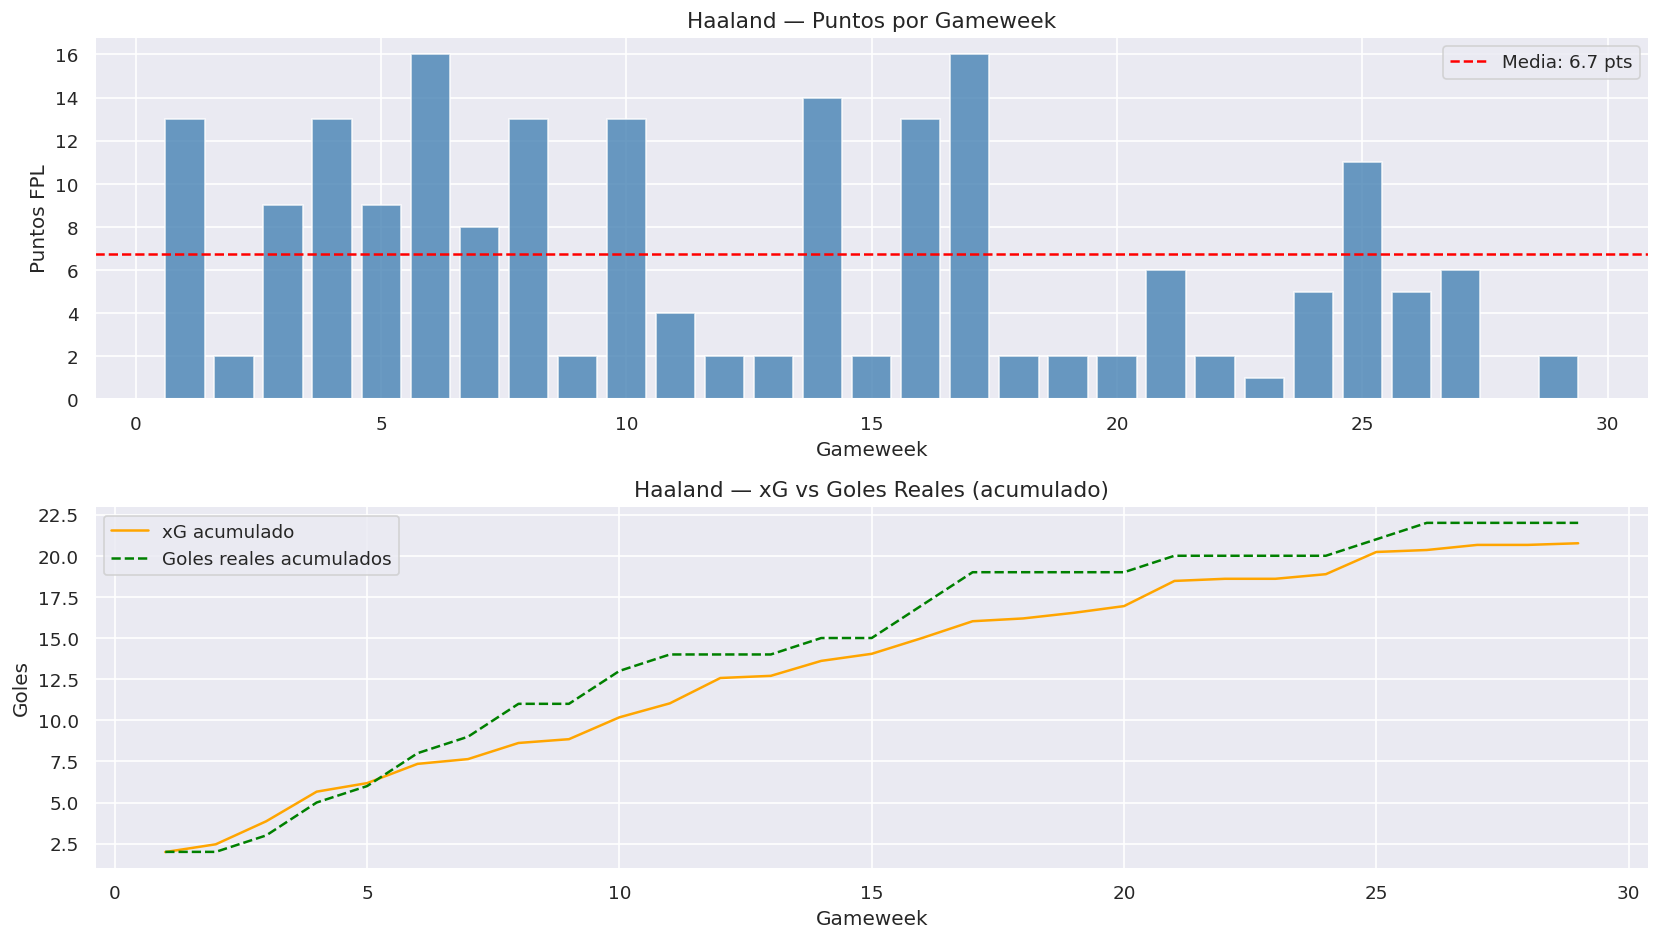

In [12]:
# Visualización de puntos por GW para el jugador top
if 'total_points' in history.columns and 'round' in history.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Puntos por GW
    axes[0].bar(history['round'], history['total_points'],
                color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axhline(history['total_points'].mean(), color='red',
                    linestyle='--', label=f"Media: {history['total_points'].mean():.1f} pts")
    axes[0].set_title(f"{top_scorer['web_name']} — Puntos por Gameweek", fontsize=13)
    axes[0].set_xlabel('Gameweek')
    axes[0].set_ylabel('Puntos FPL')
    axes[0].legend()
    
    # xG vs goles reales
    if 'expected_goals' in history.columns:
        xg = pd.to_numeric(history['expected_goals'], errors='coerce').fillna(0)
        axes[1].plot(history['round'], xg.cumsum(), label='xG acumulado', color='orange')
        axes[1].plot(history['round'], history['goals_scored'].cumsum(),
                     label='Goles reales acumulados', color='green', linestyle='--')
        axes[1].set_title(f"{top_scorer['web_name']} — xG vs Goles Reales (acumulado)", fontsize=13)
        axes[1].set_xlabel('Gameweek')
        axes[1].set_ylabel('Goles')
        axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(DATA_DIR / f'player_{top_scorer["id"]}_history.png', dpi=150)
    plt.show()

## ⚡ 9. Live data — Puntos en tiempo real (último GW)

In [13]:
def get_live_gw(gameweek):
    """Obtiene puntos en vivo de todos los jugadores para un GW."""
    data = get_fpl_data(f'event/{gameweek}/live/')
    rows = []
    for player in data['elements']:
        stats = player['stats']
        stats['id'] = player['id']
        rows.append(stats)
    return pd.DataFrame(rows)

# Usar el GW actual o el último completado
if len(current_gw) > 0:
    gw_id = int(current_gw['id'].values[0])
else:
    gw_id = int(df_gw[df_gw['finished']]['id'].max())

print(f'⚡ Cargando datos live del GW{gw_id}...')
df_live = get_live_gw(gw_id)

# Unir con nombres de jugadores
df_live = df_live.merge(
    df_players[['id', 'web_name', 'position', 'team_name', 'price_M']],
    on='id', how='left'
)

print(f'✅ {len(df_live)} jugadores con datos para GW{gw_id}')
print('\n🏆 Top 10 jugadores del GW:')
df_live.sort_values('total_points', ascending=False) \
    [['web_name', 'position', 'team_name', 'total_points', 'goals_scored', 'assists', 'bonus']] \
    .head(10).to_string(index=False)

⚡ Cargando datos live del GW29...
✅ 820 jugadores con datos para GW29

🏆 Top 10 jugadores del GW:


"   web_name position      team_name  total_points  goals_scored  assists  bonus\n João Pedro      FWD        Chelsea            19             3        1      3\n       Sarr      MID Crystal Palace            15             2        0      3\n  Tarkowski      DEF        Everton            15             1        0      3\n   J.Timber      DEF        Arsenal            13             0        1      2\n      André      MID         Wolves            12             1        0      3\n   Anderson      MID  Nott'm Forest            12             1        0      3\n     Senesi      DEF    Bournemouth            11             0        0      3\nSummerville      MID       West Ham            11             1        0      3\n    Gabriel      DEF        Arsenal            11             0        0      3\n    Ellborg      GKP     Sunderland            10             0        0      3"

## 📈 10. Análisis exploratorio de datos (EDA)

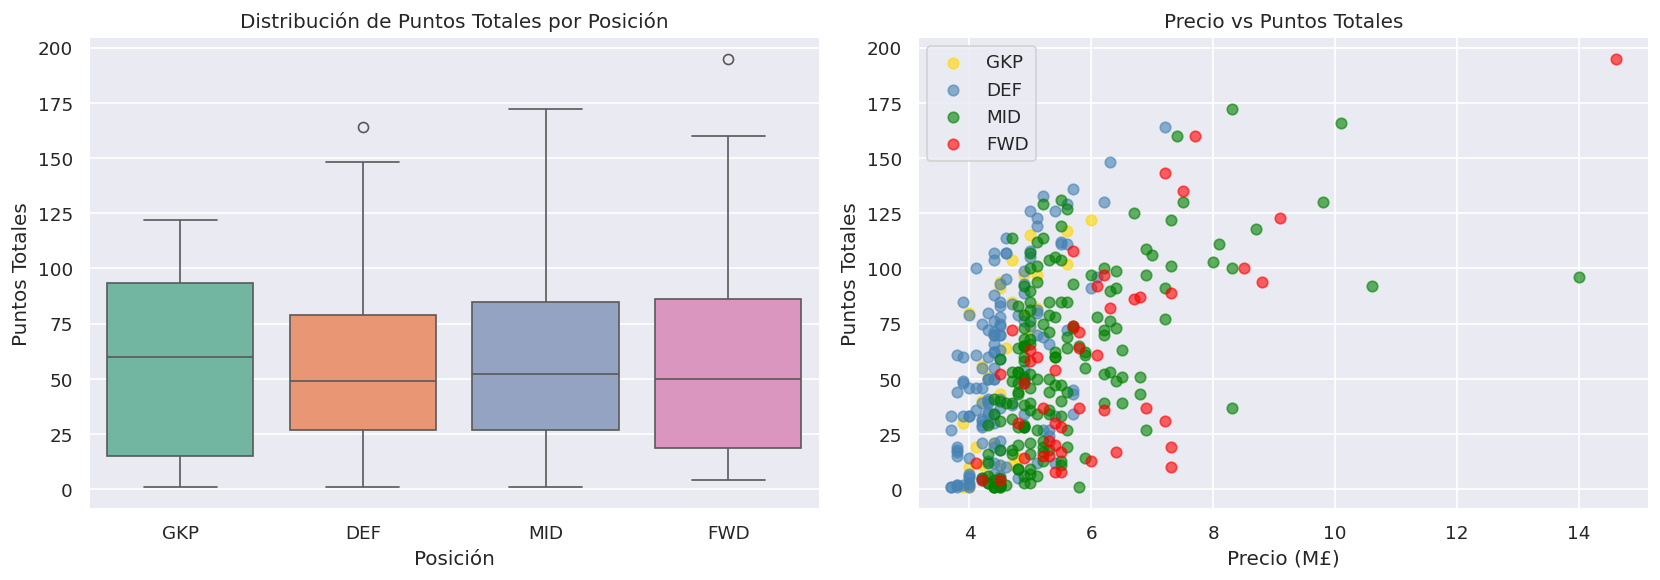

In [14]:
# Distribución de puntos por posición
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: puntos totales
pos_order = ['GKP', 'DEF', 'MID', 'FWD']
active = df_players[(df_players['status'] == 'a') & (df_players['total_points'] > 0)]

sns.boxplot(data=active, x='position', y='total_points',
            order=pos_order, palette='Set2', ax=axes[0])
axes[0].set_title('Distribución de Puntos Totales por Posición', fontsize=12)
axes[0].set_xlabel('Posición')
axes[0].set_ylabel('Puntos Totales')

# Scatter: precio vs puntos
colors = {'GKP': 'gold', 'DEF': 'steelblue', 'MID': 'green', 'FWD': 'red'}
for pos in pos_order:
    subset = active[active['position'] == pos]
    axes[1].scatter(subset['price_M'], subset['total_points'],
                    label=pos, alpha=0.6, color=colors[pos], s=40)

axes[1].set_title('Precio vs Puntos Totales', fontsize=12)
axes[1].set_xlabel('Precio (M£)')
axes[1].set_ylabel('Puntos Totales')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_points_price.png', dpi=150)
plt.show()

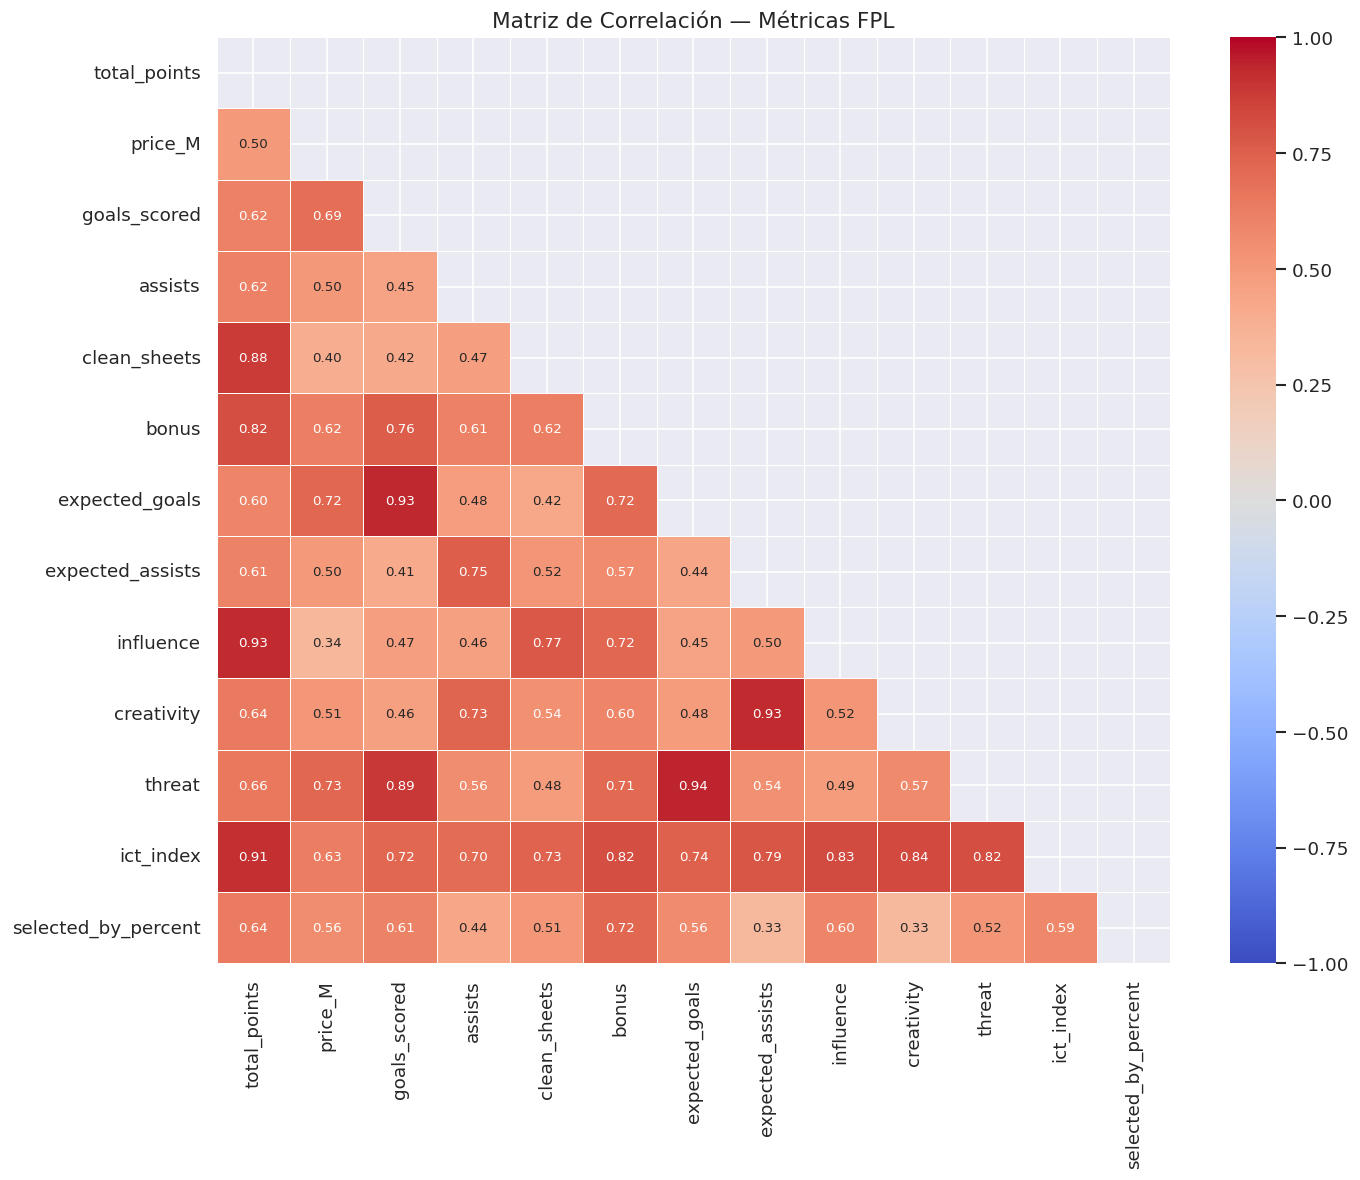

In [15]:
# Matriz de correlación — métricas avanzadas
corr_cols = ['total_points', 'price_M', 'goals_scored', 'assists',
             'clean_sheets', 'bonus',
             'expected_goals', 'expected_assists',
             'influence', 'creativity', 'threat', 'ict_index',
             'selected_by_percent']

corr_matrix = active[corr_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de Correlación — Métricas FPL', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'correlation_matrix.png', dpi=150)
plt.show()

## 💾 11. Guardar todos los datasets como CSV

In [16]:
# Guardar todos los DataFrames
df_players.to_csv(DATA_DIR / 'players.csv', index=False)
df_teams.to_csv(DATA_DIR / 'teams.csv', index=False)
df_gw.to_csv(DATA_DIR / 'gameweeks.csv', index=False)
df_fixtures.to_csv(DATA_DIR / 'fixtures.csv', index=False)
df_live.to_csv(DATA_DIR / f'live_gw{gw_id}.csv', index=False)

print('💾 Archivos guardados en ./fpl_data/')
for f in sorted(DATA_DIR.glob('*.csv')):
    df_temp = pd.read_csv(f)
    print(f'  ✅ {f.name}: {len(df_temp):,} filas × {len(df_temp.columns)} columnas')

💾 Archivos guardados en ./fpl_data/
  ✅ fixtures.csv: 380 filas × 19 columnas
  ✅ gameweeks.csv: 38 filas × 10 columnas
  ✅ live_gw29.csv: 820 filas × 33 columnas
  ✅ players.csv: 820 filas × 38 columnas
  ✅ teams.csv: 20 filas × 10 columnas


## 🤖 12. Preparación para Machine Learning

IndexError: boolean index did not match indexed array along axis 0; size of axis is 365 but size of corresponding boolean axis is 15

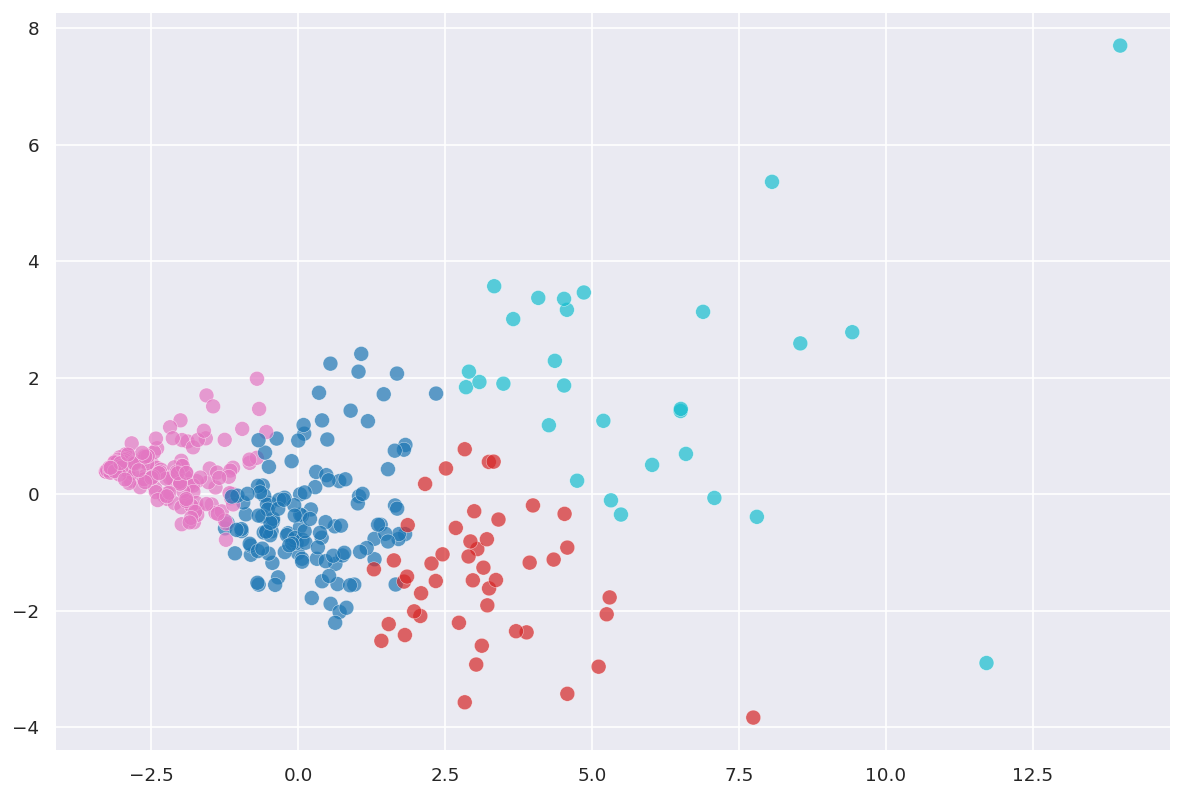

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Features para clustering de jugadores (outfield)
outfield = active[active['position'].isin(['DEF', 'MID', 'FWD'])].copy()

features = [
    'total_points', 'price_M', 'goals_scored', 'assists',
    'clean_sheets', 'bonus', 'expected_goals', 'expected_assists',
    'influence', 'creativity', 'threat'
]

X = outfield[features].dropna()
player_names = outfield.loc[X.index, 'web_name']
player_positions = outfield.loc[X.index, 'position']

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2D para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Visualizar clusters
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=clusters, cmap='tab10',
                     alpha=0.7, s=80, edgecolors='white', linewidth=0.3)

# Etiquetar top jugadores
top_idx = X.index[X['total_points'].nlargest(15).index.isin(X.index)]
for idx in X.nlargest(12, 'total_points').index:
    i = list(X.index).index(idx)
    ax.annotate(player_names[idx],
                (X_pca[i, 0], X_pca[i, 1]),
                fontsize=7, ha='center', va='bottom')

ax.set_title('Clustering de Jugadores FPL (KMeans, k=4) — PCA 2D', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig(DATA_DIR / 'player_clusters.png', dpi=150)
plt.show()

print(f'✅ Varianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_):.1%}')

## 📋 13. Resumen de endpoints adicionales (referencia)

In [ ]:
# Función genérica para explorar cualquier endpoint
def explore_endpoint(endpoint, max_items=3):
    """Muestra la estructura de cualquier endpoint FPL."""
    try:
        data = get_fpl_data(endpoint)
        if isinstance(data, list):
            df = pd.DataFrame(data[:max_items])
            print(f'\n🔗 {BASE_URL}{endpoint}')
            print(f'   Tipo: lista de {len(data)} elementos')
            print(f'   Columnas: {list(df.columns)}')
        elif isinstance(data, dict):
            print(f'\n🔗 {BASE_URL}{endpoint}')
            print(f'   Tipo: objeto con claves: {list(data.keys())}')
    except Exception as e:
        print(f'   ❌ Error: {e}')

# Explorar score ruling
print('📚 Reglas de puntuación FPL:')
scoring = bootstrap['game_config']['scoring']
for k, v in scoring.items():
    if isinstance(v, dict):
        print(f'  {k}: {v}')
    elif v != 0:
        print(f'  {k}: {v}')

In [ ]:
print('\n✅ Extracción completa de datos FPL finalizada!')
print(f'📁 Datos guardados en: {DATA_DIR.absolute()}')
print(f'📊 Jugadores analizados: {len(df_players)}')
print(f'🏟️  Equipos: {len(df_teams)}')
print(f'📅 Gameweeks: {len(df_gw)}')
print(f'⚽ Fixtures: {len(df_fixtures)}')